In [2]:
# ============================================================
# Diabetes Tool - Model Training & Evaluation
# XGBoost Classifier with SHAP Explainability
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report, 
                             confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import shap
import joblib

# Paths — works regardless of where Jupyter is launched from
PROJECT_ROOT = Path().resolve().parent
if PROJECT_ROOT.name != 'diabetes-tool':
    PROJECT_ROOT = PROJECT_ROOT / 'diabetes-tool'

PROCESSED_DATA = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR = PROJECT_ROOT / 'backend' / 'ml'

print("Project root:", PROJECT_ROOT)

# Load harmonized dataset
df = pd.read_csv(PROCESSED_DATA / 'harmonized_diabetes.csv')

print("Harmonized dataset loaded:")
print(f"  Shape: {df.shape}")
print(f"  Diabetes rate: {df['diabetes_label'].mean()*100:.1f}%")
print(f"  Sources: {df['source'].value_counts().to_dict()}")

Project root: /Users/rohingupta/Developer/diabetes-tool
Harmonized dataset loaded:
  Shape: (254968, 18)
  Diabetes rate: 14.1%
  Sources: {'brfss': 253680, 'pima': 768, 'sylhet': 520}


In [3]:
# ============================================================
# STEP 1: Prepare Features for Training
# ============================================================

# Drop print of project root for clean output
# Features we'll use for the risk model
# Only include features a user can realistically self-report
FEATURES = [
    'age', 'gender', 'bmi',
    'high_bp', 'high_cholesterol', 'smoker', 'physically_active',
    'polyuria', 'polydipsia', 'sudden_weight_loss'
]

TARGET = 'diabetes_label'

# Drop rows where target is missing
df_model = df.dropna(subset=[TARGET])

# For features, we'll use what's available per row
# Rows missing all features are useless — drop them
df_model = df_model.dropna(subset=FEATURES, how='all')

# Split features and target
X = df_model[FEATURES]
y = df_model[TARGET]

print("Training data prepared:")
print(f"  Total samples: {len(df_model)}")
print(f"  Features: {FEATURES}")
print(f"  Class distribution:")
print(f"    No Diabetes: {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"    Diabetes:    {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")
print(f"\n  Missing values per feature:")
print(X.isnull().sum())

Training data prepared:
  Total samples: 254968
  Features: ['age', 'gender', 'bmi', 'high_bp', 'high_cholesterol', 'smoker', 'physically_active', 'polyuria', 'polydipsia', 'sudden_weight_loss']
  Class distribution:
    No Diabetes: 219034 (85.9%)
    Diabetes:    35934 (14.1%)

  Missing values per feature:
age                        0
gender                   768
bmi                      520
high_bp                 1288
high_cholesterol        1288
smoker                  1288
physically_active       1288
polyuria              254448
polydipsia            254448
sudden_weight_loss    254448
dtype: int64


In [4]:
# ============================================================
# STEP 2: Handle Missing Values & Train/Test Split
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Split first — impute after to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Impute missing values with median
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train), 
    columns=FEATURES
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test), 
    columns=FEATURES
)

print("Train/Test split complete:")
print(f"  Training samples:   {len(X_train_imputed)}")
print(f"  Test samples:       {len(X_test_imputed)}")
print(f"\n  Training class distribution:")
print(f"    No Diabetes: {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
print(f"    Diabetes:    {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)")
print(f"\n  Missing values after imputation: {X_train_imputed.isnull().sum().sum()}")

Train/Test split complete:
  Training samples:   203974
  Test samples:       50994

  Training class distribution:
    No Diabetes: 175227 (85.9%)
    Diabetes:    28747 (14.1%)

  Missing values after imputation: 0


In [5]:
# ============================================================
# STEP 3: Baseline Model - Logistic Regression
# ============================================================

from sklearn.preprocessing import StandardScaler

# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Train baseline
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Evaluate
lr_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_pred = lr.predict(X_test_scaled)
lr_auc = roc_auc_score(y_test, lr_pred_proba)

print("Logistic Regression Baseline:")
print(f"  ROC-AUC: {lr_auc:.4f}")
print(f"\n  Classification Report:")
print(classification_report(y_test, lr_pred, 
      target_names=['No Diabetes', 'Diabetes']))

Logistic Regression Baseline:
  ROC-AUC: 0.7893

  Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.94      0.69      0.80     43807
    Diabetes       0.28      0.74      0.41      7187

    accuracy                           0.70     50994
   macro avg       0.61      0.72      0.60     50994
weighted avg       0.85      0.70      0.74     50994



In [6]:
# ============================================================
# STEP 4: XGBoost Model
# ============================================================

# Calculate scale_pos_weight to handle class imbalance
# ratio of negative to positive samples
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=20,
    verbosity=0
)

xgb_model.fit(
    X_train_imputed, y_train,
    eval_set=[(X_test_imputed, y_test)],
    verbose=False
)

# Evaluate
xgb_pred_proba = xgb_model.predict_proba(X_test_imputed)[:, 1]
xgb_pred = xgb_model.predict(X_test_imputed)
xgb_auc = roc_auc_score(y_test, xgb_pred_proba)

print(f"\nXGBoost Results:")
print(f"  ROC-AUC: {xgb_auc:.4f}")
print(f"  Improvement over baseline: +{(xgb_auc - lr_auc):.4f}")
print(f"\n  Classification Report:")
print(classification_report(y_test, xgb_pred,
      target_names=['No Diabetes', 'Diabetes']))

scale_pos_weight: 6.10

XGBoost Results:
  ROC-AUC: 0.7978
  Improvement over baseline: +0.0085

  Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.95      0.68      0.79     43807
    Diabetes       0.28      0.77      0.41      7187

    accuracy                           0.69     50994
   macro avg       0.61      0.72      0.60     50994
weighted avg       0.85      0.69      0.74     50994



In [7]:
# ============================================================
# STEP 5: Stratified K-Fold Cross Validation
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        verbosity=0
    ),
    X_train_imputed, y_train,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

print("5-Fold Stratified Cross Validation:")
print(f"  Fold scores: {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean AUC:    {cv_scores.mean():.4f}")
print(f"  Std AUC:     {cv_scores.std():.4f}")
print(f"  95% CI:      ({cv_scores.mean() - 2*cv_scores.std():.4f}, "
      f"{cv_scores.mean() + 2*cv_scores.std():.4f})")

5-Fold Stratified Cross Validation:
  Fold scores: ['0.7944', '0.7929', '0.7904', '0.7957', '0.7959']
  Mean AUC:    0.7938
  Std AUC:     0.0020
  95% CI:      (0.7897, 0.7979)


Computing SHAP values...


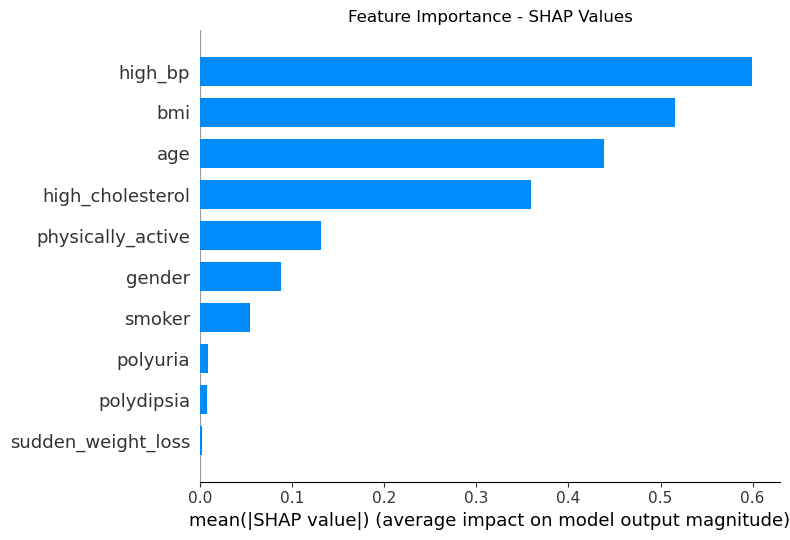

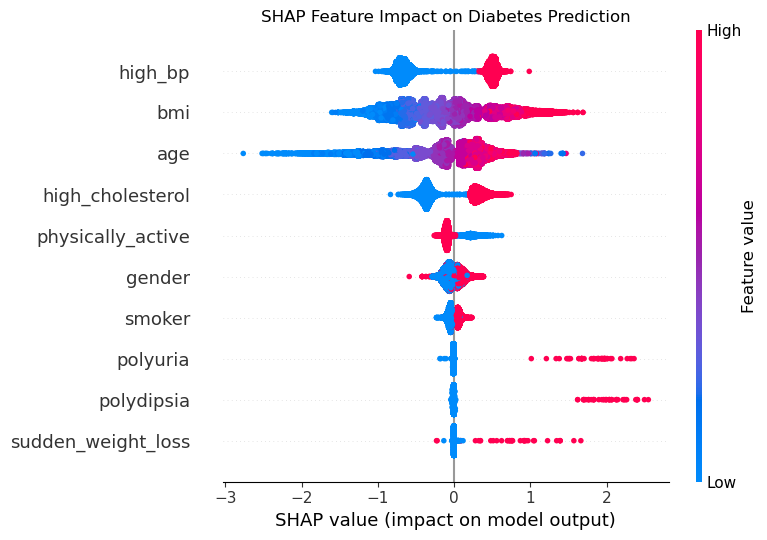

SHAP plots saved


In [8]:
# ============================================================
# STEP 6: SHAP Explainability
# ============================================================

print("Computing SHAP values...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_imputed)

# Summary plot - feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_imputed, 
                  feature_names=FEATURES,
                  plot_type='bar',
                  show=False)
plt.title('Feature Importance - SHAP Values')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'shap_importance.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# Detailed SHAP plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_imputed,
                  feature_names=FEATURES,
                  show=False)
plt.title('SHAP Feature Impact on Diabetes Prediction')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'shap_detailed.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plots saved")

In [9]:
# ============================================================
# STEP 7: Save Model and Artifacts
# ============================================================

MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save XGBoost model
joblib.dump(xgb_model, MODEL_DIR / 'xgb_diabetes_model.pkl')

# Save imputer
joblib.dump(imputer, MODEL_DIR / 'imputer.pkl')

# Save feature list
joblib.dump(FEATURES, MODEL_DIR / 'features.pkl')

# Save model metadata
import json
metadata = {
    'model': 'XGBoostClassifier',
    'version': '1.0.0',
    'features': FEATURES,
    'roc_auc_test': round(xgb_auc, 4),
    'roc_auc_cv_mean': round(cv_scores.mean(), 4),
    'roc_auc_cv_std': round(cv_scores.std(), 4),
    'training_samples': len(X_train_imputed),
    'test_samples': len(X_test_imputed),
    'diabetes_rate_train': round(y_train.mean(), 4),
    'datasets': ['PIMA Indians', 'CDC BRFSS', 'Sylhet'],
    'scale_pos_weight': round(scale_pos_weight, 2),
    'limitations': [
        'BRFSS dominates training data (99.5% of samples)',
        'Sylhet features (polyuria, polydipsia) underrepresented',
        'No Indian population specific data',
        'Survey-based features may not reflect clinical measurements'
    ]
}

with open(MODEL_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Model artifacts saved:")
print(f"  xgb_diabetes_model.pkl")
print(f"  imputer.pkl")
print(f"  features.pkl")
print(f"  model_metadata.json")
print(f"\nModel metadata:")
print(json.dumps(metadata, indent=2))

Model artifacts saved:
  xgb_diabetes_model.pkl
  imputer.pkl
  features.pkl
  model_metadata.json

Model metadata:
{
  "model": "XGBoostClassifier",
  "version": "1.0.0",
  "features": [
    "age",
    "gender",
    "bmi",
    "high_bp",
    "high_cholesterol",
    "smoker",
    "physically_active",
    "polyuria",
    "polydipsia",
    "sudden_weight_loss"
  ],
  "roc_auc_test": 0.7978,
  "roc_auc_cv_mean": 0.7938,
  "roc_auc_cv_std": 0.002,
  "training_samples": 203974,
  "test_samples": 50994,
  "diabetes_rate_train": 0.1409,
  "datasets": [
    "PIMA Indians",
    "CDC BRFSS",
    "Sylhet"
  ],
  "scale_pos_weight": 6.1,
  "limitations": [
    "BRFSS dominates training data (99.5% of samples)",
    "Sylhet features (polyuria, polydipsia) underrepresented",
    "No Indian population specific data",
    "Survey-based features may not reflect clinical measurements"
  ]
}


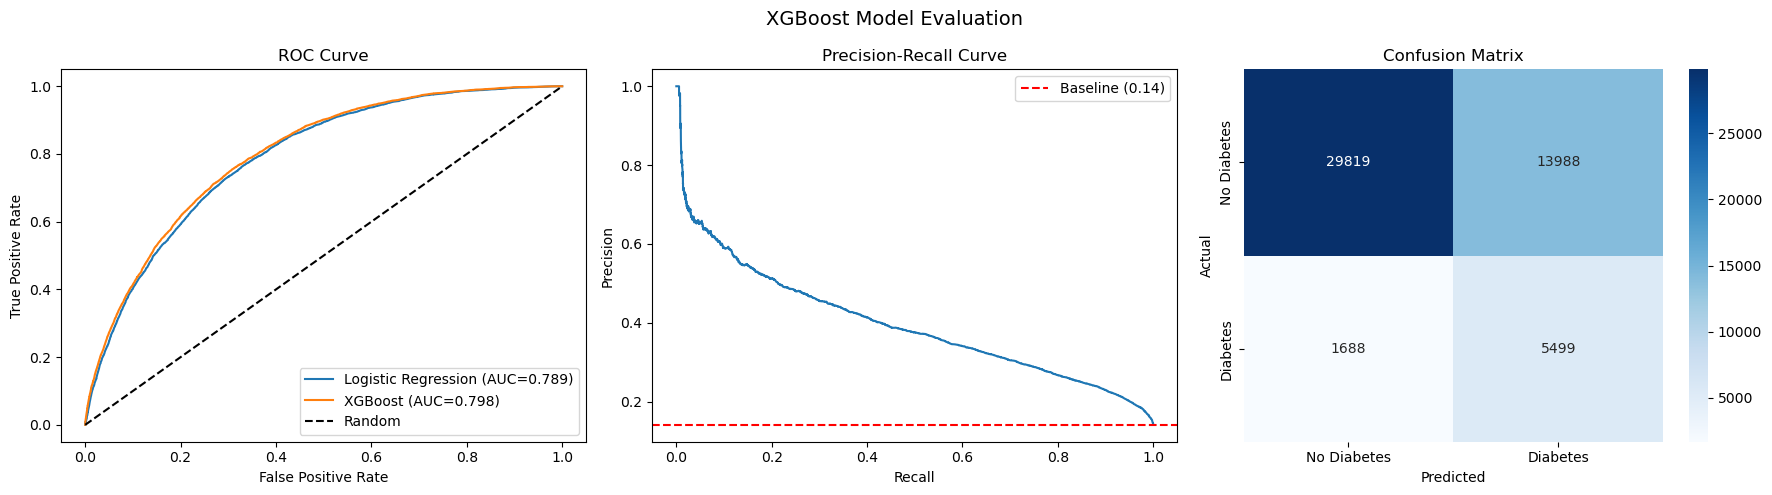

Evaluation plots saved


In [10]:
# ============================================================
# STEP 8: Final Evaluation Plots
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('XGBoost Model Evaluation', fontsize=14)

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred_proba)

axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={lr_auc:.3f})')
axes[0].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={xgb_auc:.3f})')
axes[0].plot([0,1], [0,1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall Curve
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, xgb_pred_proba)
axes[1].plot(rec_xgb, prec_xgb)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].axhline(y=y_test.mean(), color='r', linestyle='--', 
                label=f'Baseline ({y_test.mean():.2f})')
axes[1].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[2].set_title('Confusion Matrix')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'model_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Evaluation plots saved")